<a href="https://colab.research.google.com/github/beyzahiz/Cats-Dogs-CNN-Classifier/blob/main/Cats_Dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/cats_dogs_dataset"

train_dir = DATA_PATH + "/training_set"
test_dir = DATA_PATH + "/test_set"

Mounted at /content/drive


In [2]:
import tensorflow as tf
#tf.keras.utils.get_file() internetten dosya indirir

def get_datasets(data_dir):
    train_ds = tf.keras.utils.image_dataset_from_directory( #görselleri yükler, label atar, batch oluşturur
        data_dir,
        validation_split= 0.2,
        subset="training",
        seed=42,
        image_size=(150,150),
        batch_size=32
    )

    val_ds=tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="validation",
        seed=42,
        image_size=(150,150),
        batch_size=32
    )

    return train_ds, val_ds

In [3]:
#Data Augmentation
#Eldeki verileri hafifçe değiştirerek daha fazla veri varmış gibi çeşitlilik oluşturmak
#Data augmentation sadece training dataset’te olmalı.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"), #görseli yatayda rastgele çevirir
    layers.RandomRotation(0.1), #%10 oranında döndürür
    layers.RandomZoom(0.1), #Hafif yakınlaştırma
])


In [4]:
IMG_SIZE=(150,150)

model=keras.Sequential([
    layers.Input(shape=(150,150,3)),
    data_augmentation,
    layers.Rescaling(1./255), #normalizasyon

    #Conv
    #resmin üzerindeki featuresları yakalamaya yarar. resmin içindeki kenarları, köşeleri ve desenleri bulur.
    layers.Conv2D(32, (3,3), activation="relu"), #32 filtre sayısı, 3,3 kernel sayısı
    layers.MaxPooling2D(2,2), #resmi özetler, boyutu küçülür ama en önemli özellikler (mesela kedinin kulağının sivri ucu) korunur.

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"), #128 nöronla karmaşık kuralları öğrenir
    layers.Dropout(0.5), #modelin ezberlemesini engeller, sadece belirli nöronlara güvenmek yerine bilgiyi tüm ağa yaymayı öğrenir.
    layers.Dense(1, activation="sigmoid") #1 çıktı üretilir ve olasılığa dönüşür
])

In [5]:
model.summary()




Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#binary_crossentropy uygulayacağım çünkü 2 sınıf var çıktı 1 tane sigmoid kullanıyorum
#categorical_crossentropy +3 sınıf varsa softmax kullanılıyorsa

train_ds, val_ds = get_datasets(train_dir)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#Early Stopping
#model eğitimi aşamasında kullanılan callback fonksiyonu. overfitting önler
early_stop=keras.callbacks.EarlyStopping(
    monitor="val_loss", #modelin hangi değeri takip edeceği
    patience=5, #eğer val_loss değeri 5 epoch boyunca iyileşmezse eğitimi durdurur.
    restore_best_weights=True #eğitimi durdurduğunda, modelin en iyi performansı gösterdiği (hatanın en düşük olduğu) ana geri döner
)

history= model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Found 8005 files belonging to 2 classes.
Using 6404 files for training.
Found 8005 files belonging to 2 classes.
Using 1601 files for validation.
Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 724s 4s/step - accuracy: 0.5377 - loss: 0.6975 - val_accuracy: 0.6227 - val_loss: 0.6555
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 169ms/step - accuracy: 0.6050 - loss: 0.6619 - val_accuracy: 0.6009 - val_loss: 0.6486
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 35s 140ms/step - accuracy: 0.6236 - loss: 0.6519 - val_accuracy: 0.6440 - val_loss: 0.6275
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 0.6523 - loss: 0.6196 - val_accuracy: 0.7114 - val_loss: 0.5601
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.6893 - loss: 0.5855 - val_accuracy: 0.7133 - val_loss: 0.5695
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.6844 - loss: 0.5923 - val_accuracy: 0.7408 - val_loss: 0.5303
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 148ms/step - accuracy: 0.7

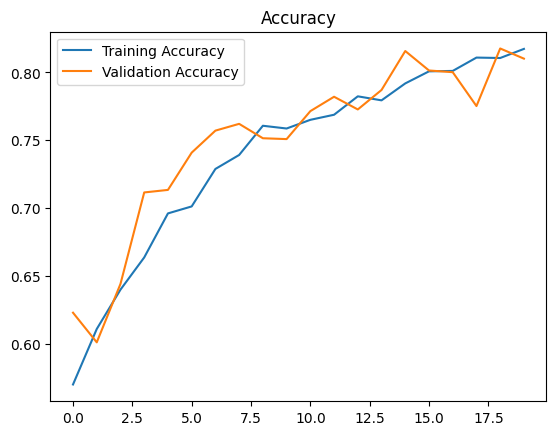

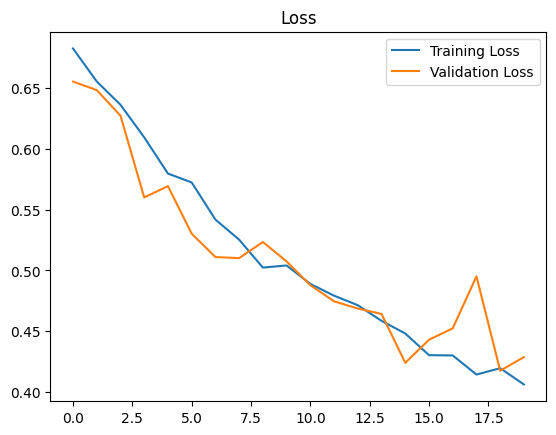

In [7]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure()
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.figure()
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.show()

In [8]:
#GlobalAveragePooling
#Tüm bir haritayı (kanalı) tek bir sayıya dönüştürür. Her channel için ortalama alır. Parametre düşer.

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 140ms/step - accuracy: 0.5155 - loss: 0.6928 - val_accuracy: 0.5447 - val_loss: 0.6909
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 0.5348 - loss: 0.6885 - val_accuracy: 0.5740 - val_loss: 0.6726
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 141ms/step - accuracy: 0.5915 - loss: 0.6701 - val_accuracy: 0.5728 - val_loss: 0.6833
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.6030 - loss: 0.6592 - val_accuracy: 0.5684 - val_loss: 0.6673
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 142ms/step - accuracy: 0.6160 - loss: 0.6550 - val_accuracy: 0.6015 - val_loss: 0.6593
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 168ms/step - accuracy: 0.6295 - loss: 0.6436 - val_accuracy: 0.6077 - val_loss: 0.6525
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.6393 - loss: 0.6342 - val_accuracy: 0.6209 - val_loss: 0.6315
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 148ms/step - accuracy: 0.6311 - loss: 0

In [10]:
#Batch Normalization
#Ağ içindeki her bir "batch" (grup) veri için şu matematiksel işlemi yapar: Verinin ortalamasını alır.
#Verinin standart sapmasını (dağılımını) hesaplar. Verileri bu değerleri kullanarak normalize eder (genellikle ortalaması 0, standart sapması 1 olacak şekilde).

model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])



In [11]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 143ms/step - accuracy: 0.5551 - loss: 0.7706 - val_accuracy: 0.4916 - val_loss: 0.8504
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 142ms/step - accuracy: 0.5930 - loss: 0.7041 - val_accuracy: 0.5640 - val_loss: 0.6809
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 140ms/step - accuracy: 0.6155 - loss: 0.6591 - val_accuracy: 0.6415 - val_loss: 0.6229
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 0.6330 - loss: 0.6431 - val_accuracy: 0.6490 - val_loss: 0.6263
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 142ms/step - accuracy: 0.6559 - loss: 0.6200 - val_accuracy: 0.5634 - val_loss: 0.7730
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 142ms/step - accuracy: 0.6696 - loss: 0.6055 - val_accuracy: 0.5122 - val_loss: 1.2768
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.6739 - loss: 0.6094 - val_accuracy: 0.6090 - val_loss: 0.7247
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 165ms/step - accuracy: 0.6925 - loss: 0

In [12]:
#ReduceLROnPlateau
#model eğitimi sırasında öğrenmenin durakladığı anları fark eder ve öğrenme oranını otomatik olarak düşürür

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5, # Yeni LR = Eski LR * factor, öğrenme oranını 5 kat düşürür
    patience=2,
    min_lr=1e-6, #Öğrenme oranının düşebileceği en alt sınır
    verbose=1
)

history=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 151ms/step - accuracy: 0.7216 - loss: 0.5391 - val_accuracy: 0.6583 - val_loss: 0.6600 - learning_rate: 0.0010
Epoch 2/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 40s 145ms/step - accuracy: 0.7227 - loss: 0.5383 - val_accuracy: 0.7139 - val_loss: 0.5573 - learning_rate: 0.0010
Epoch 3/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 149ms/step - accuracy: 0.7360 - loss: 0.5357 - val_accuracy: 0.5665 - val_loss: 0.9943 - learning_rate: 0.0010
Epoch 4/25
200/201 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.7311 - loss: 0.5264
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 147ms/step - accuracy: 0.7312 - loss: 0.5263 - val_accuracy: 0.7089 - val_loss: 0.5638 - learning_rate: 0.0010
Epoch 5/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 147ms/step - accuracy: 0.7481 - loss: 0.5110 - val_accuracy: 0.7370 - val_loss: 0.5496 - learning_rate: 5.0000e-04
Epoch 6/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - accuracy: 0

In [14]:
#DropOut
model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 150ms/step - accuracy: 0.5859 - loss: 0.7074 - val_accuracy: 0.4916 - val_loss: 0.8184
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 40s 148ms/step - accuracy: 0.6132 - loss: 0.6514 - val_accuracy: 0.5084 - val_loss: 0.8173
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 148ms/step - accuracy: 0.6447 - loss: 0.6322 - val_accuracy: 0.5222 - val_loss: 0.8991
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - accuracy: 0.6575 - loss: 0.6187 - val_accuracy: 0.6059 - val_loss: 0.6583
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - accuracy: 0.6945 - loss: 0.5782 - val_accuracy: 0.5141 - val_loss: 1.4525
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 35s 176ms/step - accuracy: 0.6923 - loss: 0.5842 - val_accuracy: 0.5753 - val_loss: 0.8445
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 147ms/step - accuracy: 0.7083 - loss: 0.5702 - val_accuracy: 0.5166 - val_loss: 1.7456
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.7095 - loss: 0

In [15]:
#Learning Rate Tuning

model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 148ms/step - accuracy: 0.5660 - loss: 0.8031 - val_accuracy: 0.4916 - val_loss: 0.9028
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 148ms/step - accuracy: 0.5909 - loss: 0.6935 - val_accuracy: 0.6002 - val_loss: 0.6677
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 151ms/step - accuracy: 0.6267 - loss: 0.6565 - val_accuracy: 0.5840 - val_loss: 0.7112
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.6269 - loss: 0.6538 - val_accuracy: 0.6159 - val_loss: 0.6406
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 146ms/step - accuracy: 0.6539 - loss: 0.6239 - val_accuracy: 0.5778 - val_loss: 0.7039
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - accuracy: 0.6600 - loss: 0.6131 - val_accuracy: 0.6165 - val_loss: 0.6771
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 144ms/step - accuracy: 0.6734 - loss: 0.5994 - val_accuracy: 0.6852 - val_loss: 0.5914
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - accuracy: 0.6987 - loss: 0

In [19]:
model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(128,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.4),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 35s 157ms/step - accuracy: 0.5597 - loss: 0.7333 - val_accuracy: 0.4916 - val_loss: 0.9695
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 31s 152ms/step - accuracy: 0.5765 - loss: 0.7065 - val_accuracy: 0.4953 - val_loss: 0.9897
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 31s 153ms/step - accuracy: 0.6036 - loss: 0.6899 - val_accuracy: 0.5497 - val_loss: 0.8707
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 150ms/step - accuracy: 0.6058 - loss: 0.6895 - val_accuracy: 0.6184 - val_loss: 0.6912
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 31s 154ms/step - accuracy: 0.6160 - loss: 0.6717 - val_accuracy: 0.6271 - val_loss: 0.6793
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 150ms/step - accuracy: 0.6194 - loss: 0.6633 - val_accuracy: 0.6552 - val_loss: 0.6788
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 149ms/step - accuracy: 0.6280 - loss: 0.6523 - val_accuracy: 0.6690 - val_loss: 0.6432
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 31s 152ms/step - accuracy: 0.6404 - loss: 0

- BatchNorm neden ReLU’dan önce?
BatchNorm ne yapıyor?
Çıktının ortalamasını 0’a yaklaştırır. Standart sapmasını 1’e yaklaştırır. Aktivasyonları stabilize eder

Eğer ReLU’dan sonra BN olursa:
ReLU negatifleri sıfırlar → dağılım bozulur. Sonra BN tekrar normalize etmeye çalışır. Bu stabil değildir.

BN, aktivasyondan önce dağılımı düzenler. Sonra ReLU temiz, dengeli veri alır.
Bu yüzden doğru sıralama: Conv → BN → ReLU

- Dropout neden BN’den sonra?
BatchNorm istatistik hesaplar: Ortalama, Varyans

Dropout önce olursa: Rastgele nöronlar kapanır. Dağılım her batch’te değişir. BN'nin hesapladığı istatistikler tutarsız olur. Bu modelin öğrenmesini zorlaştırır.

Doğru sıra: Conv → BN → ReLU → Dropout
